[Шаг 1] Размеры кластеров Nk = [210 551 364 184  55 255 881], сумма = 2500
[Шаг 2] Центры сгенерированы на интервале (-0.30, 0.30)
[Шаг 4] Итоговая матрица Y имеет форму (2500, 15)


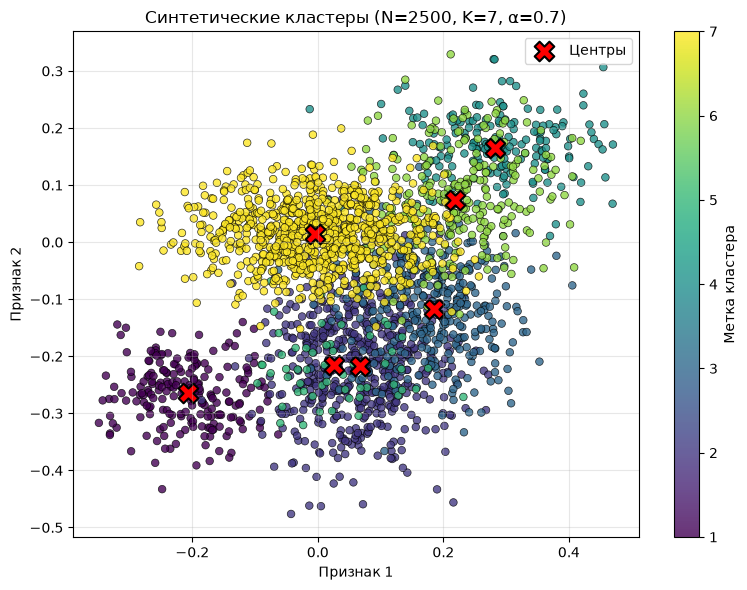


Все проверки пройдены ✓


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def clum(k, N, nmin):
    """
    Генерирует k размеров кластеров, сумма которых равна N;
    каждый размер не меньше nmin (шаг 1 алгоритма).
    """
    N_rem = N - k * nmin
    if N_rem < 0:
        raise ValueError(f"N={N} слишком мало для k={k} кластеров размером nmin={nmin}.")
    if N_rem == 0:
        return np.full(k, nmin, dtype=int)

    n0 = np.random.randint(1, N_rem + 1, size=k - 1)
    n0 = np.append(n0, N_rem)
    dd = np.sort(n0)[::-1]

    Nk = np.empty(k, dtype=int)
    Nk[:-1] = dd[:-1] - dd[1:]
    Nk[-1] = dd[-1]
    Nk = Nk + nmin
    return Nk


def generate_clusters(N, V, K, n_min, alpha, seed=None):
    """
    Генерация синтетических данных

    Параметры

    N     : int   - общее число сущностей (объектов)
    V     : int   - число признаков (размерность пространства)
    K     : int   - число кластеров (K* в описании)
    n_min : int   - минимальный размер кластера (n в описании)
    alpha : float - параметр "смешивания" кластеров, 0 < alpha < 1
                   (чем больше alpha, тем ближе центры)
    seed  : int   - зерно ГСЧ для воспроизводимости 

    Return
    
    Y      : ndarray формы (N, V) - матрица данных
    labels : ndarray формы (N,)   - скрытые метки кластеров (1..K)
    centers: ndarray формы (K, V) - сгенерированные центры кластеров
    Nk     : ndarray формы (K,)   - размеры каждого кластера
    """
    if seed is not None:
        np.random.seed(seed)

    # Проверка условия K* * n < N
    if K * n_min >= N:
        raise ValueError(
            f"Условие K*n < N нарушено: {K}*{n_min} = {K*n_min} >= {N}. "
            "Уменьшите K или n_min, либо увеличьте N."
        )
    if not (0 < alpha < 1):
        raise ValueError("Параметр alpha должен лежать в интервале (0, 1).")

    Nk = clum(K, N, n_min)
    print(f"Размеры кластеров Nk = {Nk}, сумма = {Nk.sum()}")

    low, high = alpha - 1.0, 1.0 - alpha
    centers = np.random.uniform(low, high, size=(K, V))
    print(f"Центры сгенерированы на интервале ({low:.2f}, {high:.2f})")

    Y_blocks = []
    for k in range(K):
        sk = np.random.uniform(0.05, 0.10, size=V)

        noise = np.random.normal(loc=0.0, scale=sk, size=(Nk[k], V))

        Yk = centers[k] + noise
        Y_blocks.append(Yk)

    Y = np.vstack(Y_blocks)                        # (N, V)
    labels = np.repeat(np.arange(1, K + 1), Nk)    # (N,)

    print(f" Итоговая матрица Y имеет форму {Y.shape}")
    return Y, labels, centers, Nk


if __name__ == "__main__":
    N     = 2500     # число объектов
    V     = 15       # число признаков (для визуализации)
    K     = 7       # число кластеров
    n_min = 20      # минимальный размер кластера
    alpha = 0.7     # уровень "смешивания"

    Y, labels, centers, Nk = generate_clusters(
        N=N, V=V, K=K, n_min=n_min, alpha=alpha, seed=42
    )

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(Y[:, 0], Y[:, 1], c=labels, cmap='viridis',
                            s=30, alpha=0.8, edgecolor='k', linewidth=0.5)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X',
                s=200, edgecolor='black', linewidth=1.5, label='Центры')
    plt.title(f"Синтетические кластеры (N={N}, K={K}, α={alpha})")
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")
    plt.colorbar(scatter, label="Метка кластера")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Эксперимент 1: alpha = 0.2 (Хорошо разделенные кластеры)
Silhouette Score: 0.7581
ARI:              0.9816

Эксперимент 2: alpha = 0.85 (Сильно перемешанные кластеры)
Silhouette Score: 0.3870
ARI:              0.4346



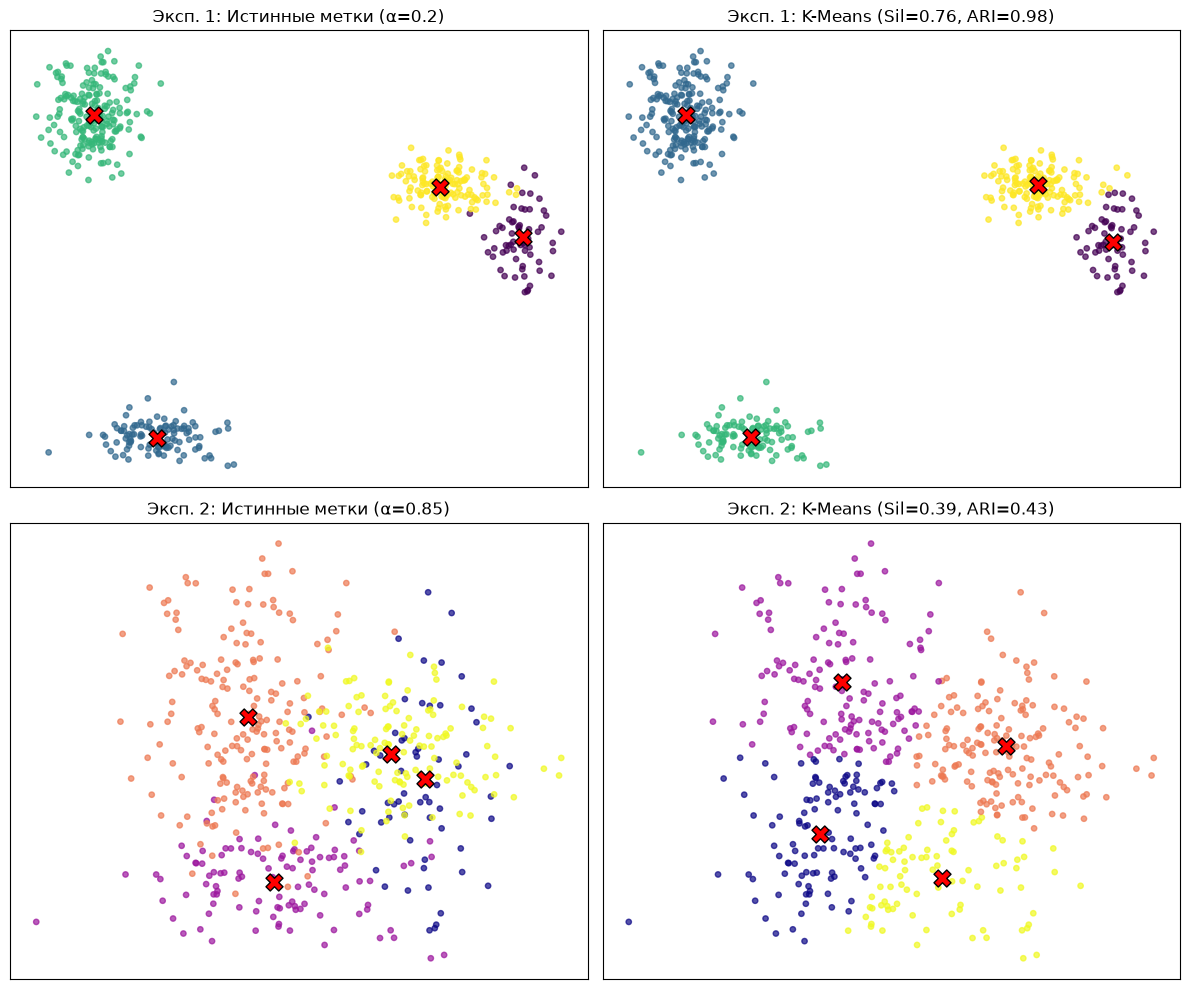

In [256]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

def clum(k, N, nmin):
    N_rem = N - k * nmin
    if N_rem < 0:
        raise ValueError(f"N={N} слишком мало для k={k} кластеров размером nmin={nmin}.")
    if N_rem == 0:
        return np.full(k, nmin, dtype=int)
    n0 = np.random.randint(1, N_rem + 1, size=k - 1)
    n0 = np.append(n0, N_rem)
    dd = np.sort(n0)[::-1]
    Nk = np.empty(k, dtype=int)
    Nk[:-1] = dd[:-1] - dd[1:]
    Nk[-1] = dd[-1]
    return Nk + nmin

def generate_clusters(N, V, K, n_min, alpha, seed=None):
    if seed is not None:
        np.random.seed(seed)
    if K * n_min >= N:
        raise ValueError("Условие K*n_min < N нарушено.")
    
    Nk = clum(K, N, n_min)
    centers = np.random.uniform(alpha - 1.0, 1.0 - alpha, size=(K, V))
    
    Y_blocks = []
    for k in range(K):
        sk = np.random.uniform(0.05, 0.10, size=V)
        noise = np.random.normal(loc=0.0, scale=sk, size=(Nk[k], V))
        Y_blocks.append(centers[k] + noise)
        
    Y = np.vstack(Y_blocks)
    labels = np.repeat(np.arange(K), Nk)
    return Y, labels, centers, Nk

def test_kmeans(Y, true_labels, K, random_state=42):
    """
    Применяет K-Means к данным Y и вычисляет метрики Silhouette и ARI.
    Возвращает: предсказанные метки, центры кластеров, Silhouette, ARI.
    """
    kmeans = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=random_state)
    pred_labels = kmeans.fit_predict(Y)
    
    sil_score = silhouette_score(Y, pred_labels)
    ari_score = adjusted_rand_score(true_labels, pred_labels)
    
    return pred_labels, kmeans.cluster_centers_, sil_score, ari_score

if __name__ == "__main__":
    N = 500
    V = 2
    K = 4
    n_min = 30
    
    print("Эксперимент 1: alpha = 0.2 (Хорошо разделенные кластеры)")
    Y1, true_labels1, centers1, _ = generate_clusters(N, V, K, n_min, alpha=0.2, seed=42)
    pred_labels1, km_centers1, sil1, ari1 = test_kmeans(Y1, true_labels1, K)
    print(f"Silhouette Score: {sil1:.4f}")
    print(f"ARI:              {ari1:.4f}\n")

    print("Эксперимент 2: alpha = 0.85 (Сильно перемешанные кластеры)")
    Y2, true_labels2, centers2, _ = generate_clusters(N, V, K, n_min, alpha=0.85, seed=42)
    pred_labels2, km_centers2, sil2, ari2 = test_kmeans(Y2, true_labels2, K)
    print(f"Silhouette Score: {sil2:.4f}")
    print(f"ARI:              {ari2:.4f}\n")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].scatter(Y1[:, 0], Y1[:, 1], c=true_labels1, cmap='viridis', s=15, alpha=0.7)
    axes[0, 0].scatter(centers1[:, 0], centers1[:, 1], c='red', marker='X', s=150, edgecolor='black', label='Истинные центры')
    axes[0, 0].set_title(f"Эксп. 1: Истинные метки (α=0.2)")
    axes[0, 0].set_xticks([])
    axes[0, 0].set_yticks([])

    axes[0, 1].scatter(Y1[:, 0], Y1[:, 1], c=pred_labels1, cmap='viridis', s=15, alpha=0.7)
    axes[0, 1].scatter(km_centers1[:, 0], km_centers1[:, 1], c='red', marker='X', s=150, edgecolor='black', label='Центры K-Means')
    axes[0, 1].set_title(f"Эксп. 1: K-Means (Sil={sil1:.2f}, ARI={ari1:.2f})")
    axes[0, 1].set_xticks([])
    axes[0, 1].set_yticks([])

    axes[1, 0].scatter(Y2[:, 0], Y2[:, 1], c=true_labels2, cmap='plasma', s=15, alpha=0.7)
    axes[1, 0].scatter(centers2[:, 0], centers2[:, 1], c='red', marker='X', s=150, edgecolor='black')
    axes[1, 0].set_title(f"Эксп. 2: Истинные метки (α=0.85)")
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])

    axes[1, 1].scatter(Y2[:, 0], Y2[:, 1], c=pred_labels2, cmap='plasma', s=15, alpha=0.7)
    axes[1, 1].scatter(km_centers2[:, 0], km_centers2[:, 1], c='red', marker='X', s=150, edgecolor='black')
    axes[1, 1].set_title(f"Эксп. 2: K-Means (Sil={sil2:.2f}, ARI={ari2:.2f})")
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])

    plt.tight_layout()
    plt.show()

 Эксперимент 1 (хорошо разделённые): alpha = 0.2
Silhouette Score: 0.7581
ARI:              0.9816



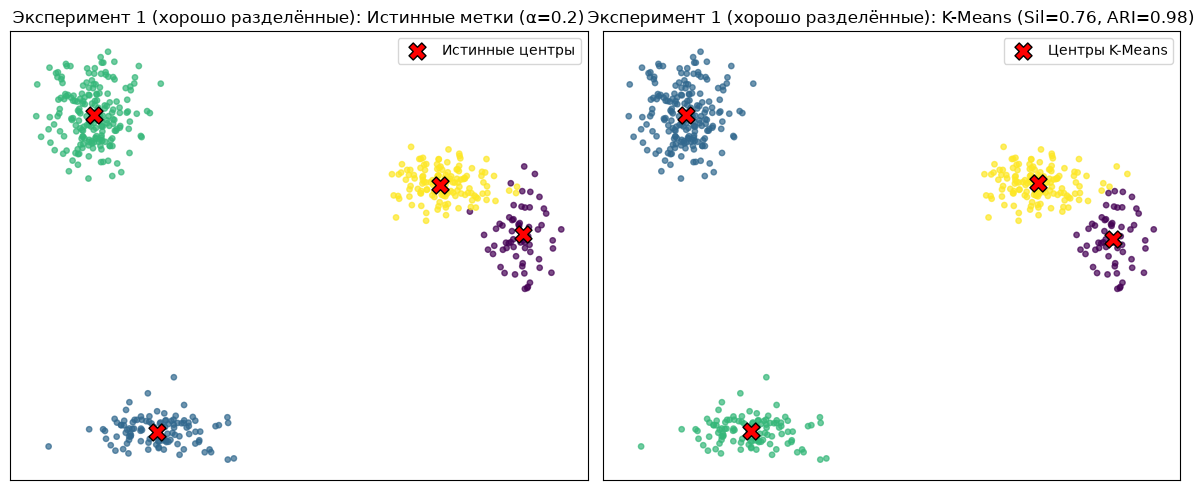

 Эксперимент 2 (сильно перемешанные): alpha = 0.85
Silhouette Score: 0.3870
ARI:              0.4346



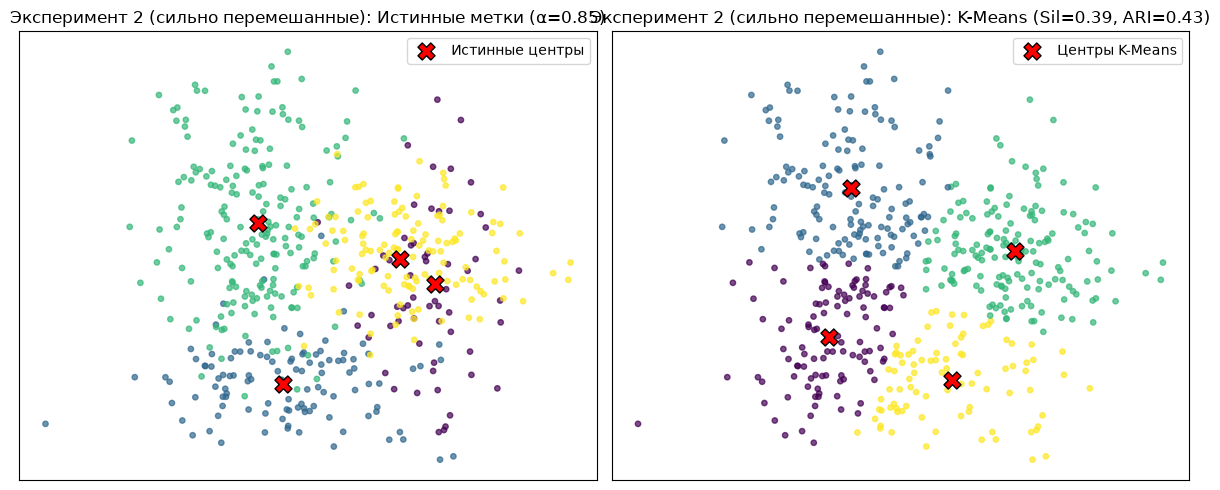

In [223]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

def run_single_experiment(alpha, seed, N, V, K, n_min, exp_name):
    """
    Запускает один эксперимент: генерация данных, тестирование K-Means, печать метрик.
    Возвращает словарь со всеми результатами.
    """
    print(f" {exp_name}: alpha = {alpha}")
    
    Y, true_labels, centers, _ = generate_clusters(N, V, K, n_min, alpha, seed)
    pred_labels, km_centers, sil, ari = test_kmeans(Y, true_labels, K)
    
    print(f"Silhouette Score: {sil:.4f}")
    print(f"ARI:              {ari:.4f}\n")
    
    return {
        'Y': Y,
        'true_labels': true_labels,
        'centers': centers,
        'pred_labels': pred_labels,
        'km_centers': km_centers,
        'sil': sil,
        'ari': ari,
        'alpha': alpha,
        'exp_name': exp_name
    }

def visualize_experiment(exp_data):
    """
    Визуализирует результаты одного эксперимента: 
    слева - истинные метки, справа - предсказания K-Means.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['true_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[0].scatter(exp_data['centers'][:, 0], exp_data['centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Истинные центры')
    axes[0].set_title(f"{exp_data['exp_name']}: Истинные метки (α={exp_data['alpha']})")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].legend(loc='upper right')
    
    axes[1].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['pred_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[1].scatter(exp_data['km_centers'][:, 0], exp_data['km_centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Центры K-Means')
    axes[1].set_title(f"{exp_data['exp_name']}: K-Means (Sil={exp_data['sil']:.2f}, ARI={exp_data['ari']:.2f})")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    N = 500
    V = 2
    K = 4
    n_min = 30
    
    exp1 = run_single_experiment(alpha=0.2, seed=42, N=N, V=V, K=K, n_min=n_min, 
                                  exp_name="Эксперимент 1 (хорошо разделённые)")
    visualize_experiment(exp1)
    
    exp2 = run_single_experiment(alpha=0.85, seed=42, N=N, V=V, K=K, n_min=n_min, 
                                  exp_name="Эксперимент 2 (сильно перемешанные)")
    visualize_experiment(exp2)

In [224]:
def visualize_experiment_b(exp_data):
    """
    Визуализирует результаты одного эксперимента: 
    слева - истинные метки, справа - предсказания K-Means.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['true_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[0].scatter(exp_data['centers'][:, 0], exp_data['centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Истинные центры')
    axes[0].set_title(f"{exp_data['exp_name']}: Истинные метки (α={exp_data['alpha']})")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].legend(loc='upper right')
    
    axes[1].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['pred_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[1].scatter(exp_data['km_centers'][:, 0], exp_data['km_centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Центры K-Means')
    axes[1].set_title(f"{exp_data['exp_name']}: K-Means (Sil={exp_data['sil']:.2f}, ARI={exp_data['ari']:.2f}, iter={exp_data['n_iter']})")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

In [225]:
def visualize_experiment_c(exp_data):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['true_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[0].scatter(exp_data['centers'][:, 0], exp_data['centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Истинные центры')
    axes[0].set_title(f"{exp_data['exp_name']}: Истинные метки (α={exp_data['alpha']})")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].legend(loc='upper right')
    
    axes[1].scatter(exp_data['Y'][:, 0], exp_data['Y'][:, 1], 
                    c=exp_data['pred_labels'], cmap='viridis', s=15, alpha=0.7)
    axes[1].scatter(exp_data['km_centers'][:, 0], exp_data['km_centers'][:, 1], 
                    c='red', marker='X', s=150, edgecolor='black', label='Центры алгоритма')
    axes[1].set_title(f"{exp_data['exp_name']}: Custom K-Means ε={exp_data['epsilon']}\n"
                      f"(Sil={exp_data['sil']:.2f}, ARI={exp_data['ari']:.2f}, iter={exp_data['n_iter']})")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()


Эксп. 1 ( классический): alpha = 0.8
Silhouette Score: 0.2325
ARI:              0.9295
Итераций:         20



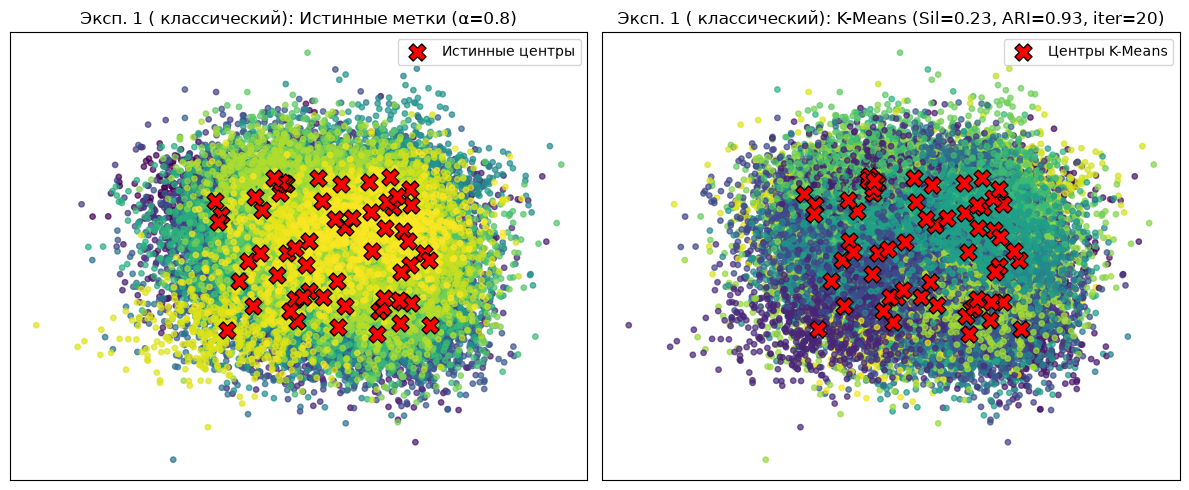

Эксп. 2 (ε=0.7, с инерцией): alpha = 0.8, epsilon = 0.1
Silhouette Score: 0.2229
ARI:              0.8900
Итераций:         28

Эксп. 2 (ε=0.7, с инерцией): alpha = 0.8, epsilon = 0.9
Silhouette Score: 0.2238
ARI:              0.8894
Итераций:         227



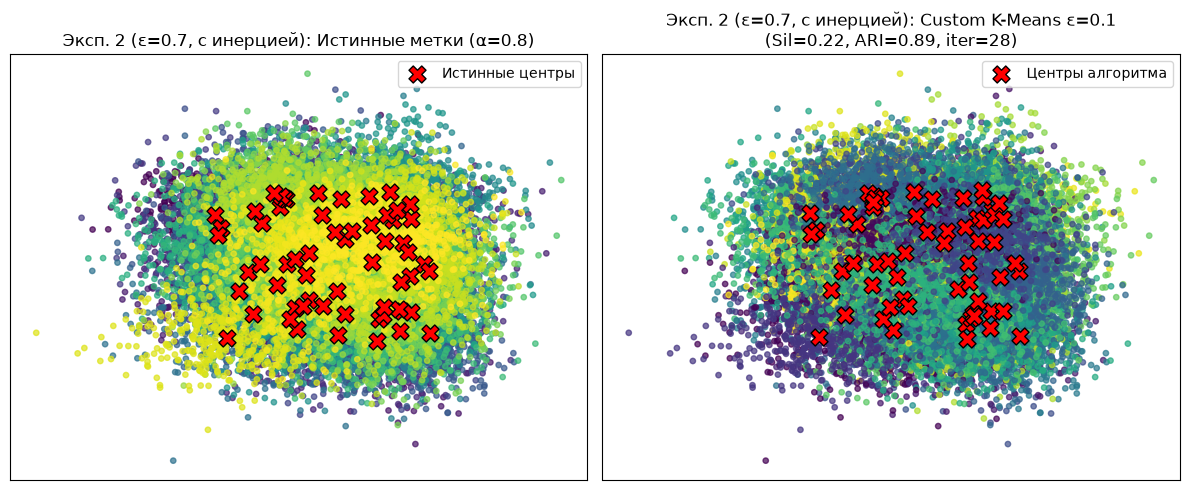

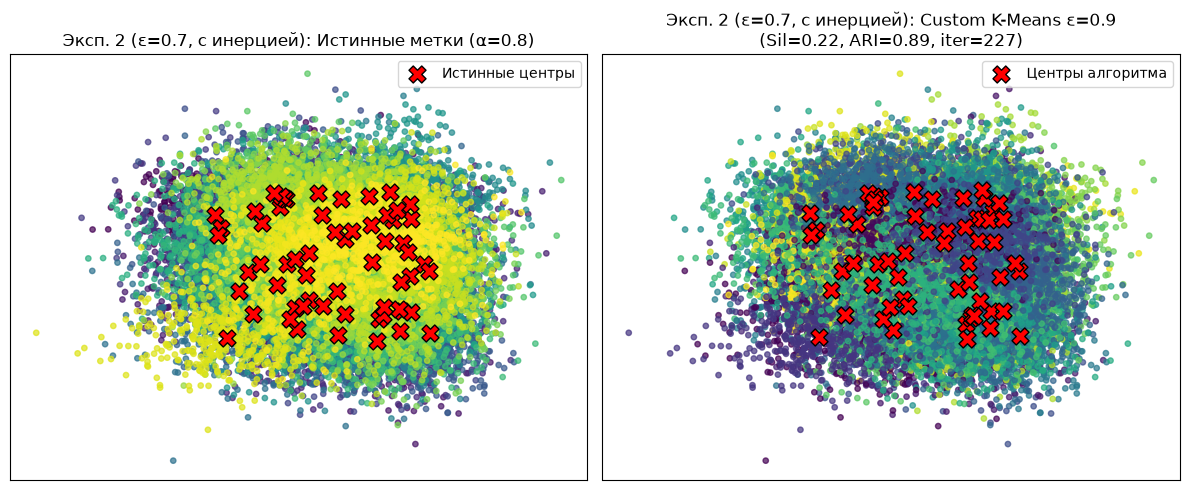

In [226]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import kmeans_plusplus


def custom_kmeans_with_inertia(X, n_clusters, epsilon=0.5, max_iter=300, tol=1e-4, 
                                random_state=None, init='k-means++'):
    """
    Модифицированный K-means с инерцией в обновлении центров.
    
    Новый центр = epsilon * C_k + (1 - epsilon) * C'_k
    
    Параметры:
    -----------
    X : ndarray формы (n_samples, n_features)
        Данные для кластеризации
    n_clusters : int
        Количество кластеров
    epsilon : float, default=0.5
        Параметр сглаживания (0 <= epsilon <= 1)
        - epsilon = 0: классический K-means
        - epsilon > 0: центры плавно сдвигаются к центрам масс
    max_iter : int, default=300
        Максимальное количество итераций
    tol : float, default=1e-4
        Порог сходимости
    random_state : int or None, default=None
        Зерно для воспроизводимости
    init : str, default='k-means++'
        Метод инициализации ('k-means++' или 'random')
    
    Возвращает:
    -----------
    centers : ndarray формы (n_clusters, n_features)
        Финальные центры кластеров
    labels : ndarray формы (n_samples,)
        Метки кластеров для каждой точки
    inertia : float
        Сумма квадратов расстояний до ближайшего центра
    n_iter : int
        Количество итераций до сходимости
    """
    if not (0 <= epsilon <= 1):
        raise ValueError("epsilon is not in interval [0, 1]")
    
    n_samples, n_features = X.shape
    rng = np.random.RandomState(random_state)
    
    if init == 'k-means++':
        centers, _ = kmeans_plusplus(X, n_clusters, random_state=rng)
    elif init == 'random':
        indices = rng.choice(n_samples, n_clusters, replace=False)
        centers = X[indices]
    else:
        raise ValueError("init должен быть 'k-means++' или 'random'")
    
    labels = np.zeros(n_samples, dtype=np.int32)
    
    for iteration in range(max_iter):
        distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
        labels = np.argmin(distances, axis=1)
        
        new_centroids = np.zeros_like(centers)
        for k in range(n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                new_centroids[k] = centers[k]
        
        # new_center = epsilon * old_center + (1 - epsilon) * centroid
        old_centers = centers.copy()
        centers = epsilon * old_centers + (1 - epsilon) * new_centroids
        
        center_shift = np.linalg.norm(centers - old_centers)
        if center_shift < tol:
            break
    
    distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
    labels = np.argmin(distances, axis=1)
    inertia = np.sum(np.min(distances, axis=1) ** 2)
    
    return centers, labels, inertia, iteration + 1

def test_kmeans(Y, true_labels, K, random_state=42):
    kmeans = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=random_state)
    pred_labels = kmeans.fit_predict(Y)
    n_iter = kmeans.n_iter_

    sil_score = silhouette_score(Y, pred_labels)
    ari_score = adjusted_rand_score(true_labels, pred_labels)
    
    return pred_labels, kmeans.cluster_centers_, n_iter, sil_score, ari_score



def test_custom_kmeans(Y, true_labels, K, epsilon=0.5, random_state=42):
    """
    Применяет модифицированный K-means и вычисляет метрики.
    """
    centers, pred_labels, inertia, n_iter = custom_kmeans_with_inertia(
        Y, n_clusters=K, epsilon=epsilon, random_state=random_state
    )
    
    sil_score = silhouette_score(Y, pred_labels)
    ari_score = adjusted_rand_score(true_labels, pred_labels)
    
    return pred_labels, centers,  n_iter, sil_score, ari_score


def run_single_experiment(alpha, seed, N, V, K, n_min, exp_name, epsilon=0.5, init = 'custom'):
    """
    Запускает один эксперимент с модифицированным K-means.
    """
    if init == 'custom':
        print(f"{exp_name}: alpha = {alpha}, epsilon = {epsilon}")

        Y, true_labels, centers, _ = generate_clusters(N, V, K, n_min, alpha, seed)
        pred_labels, km_centers, n_iter, sil, ari = test_custom_kmeans(
            Y, true_labels, K, epsilon=epsilon
        )

        print(f"Silhouette Score: {sil:.4f}")
        print(f"ARI:              {ari:.4f}")
        print(f"Итераций:         {n_iter}\n")

        return {
            'Y': Y,
            'true_labels': true_labels,
            'centers': centers,
            'pred_labels': pred_labels,
            'km_centers': km_centers,
            'sil': sil,
            'ari': ari,
            'alpha': alpha,
            'epsilon': epsilon,
            'n_iter': n_iter,
            'exp_name': exp_name
        }
    elif init == 'basic':
        print(f"{exp_name}: alpha = {alpha}")

        Y, true_labels, centers, _ = generate_clusters(N, V, K, n_min, alpha, seed)
        pred_labels, km_centers, n_iter, sil, ari = test_kmeans(Y, true_labels, K)

        print(f"Silhouette Score: {sil:.4f}")
        print(f"ARI:              {ari:.4f}")
        print(f"Итераций:         {n_iter}\n")


        return {
            'Y': Y,
            'true_labels': true_labels,
            'centers': centers,
            'pred_labels': pred_labels,
            'km_centers': km_centers,
            'sil': sil,
            'ari': ari,
            'alpha': alpha,
            'n_iter': n_iter,
            'exp_name': exp_name
        }
    else:
        raise ValueError("init должен быть 'custom' или 'basic'")
        


if __name__ == "__main__":
    N = 25000
    V = 15
    K = 60
    n_min = 400

    seed = np.random.randint(0, 2**32 - 1)
    
    exp1 = run_single_experiment(alpha=0.8, seed=seed, N=N, V=V, K=K, n_min=n_min, 
                                  exp_name="Эксп. 1 ( классический)", init = 'basic')
    visualize_experiment_b(exp1)
    
    exp2 = run_single_experiment(alpha=0.8, seed=seed, N=N, V=V, K=K, n_min=n_min, 
                                  exp_name="Эксп. 2 (ε=0.7, с инерцией)", epsilon=0.1)

    
    exp3 = run_single_experiment(alpha=0.8, seed=seed, N=N, V=V, K=K, n_min=n_min, 
                                  exp_name="Эксп. 2 (ε=0.7, с инерцией)", epsilon=0.9)
    visualize_experiment_c(exp2)
    
    visualize_experiment_c(exp3)
    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import silhouette_score
import time

N = 2500
n_min = 100  

V_list = [15, 50]
K_list = [7, 15, 21]
alpha_list = [0.5, 0.75, 0.85]
K_st_range = list(range(2, 31))
n_runs = 30  
epsilon_list = [0.1, 0.2, 0.3, 0.4]

results = {}

total_combinations = len(V_list) * len(K_list) * len(alpha_list)
current_combination = 0
global_start_time = time.time()


for V in V_list:
    results[V] = {}
    for K in K_list:
        results[V][K] = {}
        for alpha in alpha_list:
            results[V][K][alpha] = {}
            current_combination += 1
            print(f"[{current_combination}/{total_combinations}] V={V:2d}, K={K:2d}, alpha={alpha} ...", end=" ", flush=True)
            step_start = time.time()
            
            for k_st in K_st_range:
                scores_std = []
                scores_eps = {eps: [] for eps in epsilon_list}
                
                for run in range(n_runs):
                    seed = current_combination * 100000 + k_st * 1000 + run
                    Y, _, _, _ = generate_clusters(N, V, K, n_min, alpha, seed=seed)
                    
                    labels_std = KMeans(n_clusters=k_st, init='k-means++', n_init=3, random_state=seed).fit_predict(Y)
                    scores_std.append(silhouette_score(Y, labels_std))
                    
                    for eps in epsilon_list:
                        _, labels_eps, _, _ = custom_kmeans_with_inertia(
                            Y, n_clusters=k_st, epsilon=eps, random_state=seed, init='k-means++'
                        )
                        scores_eps[eps].append(silhouette_score(Y, labels_eps))
                
                results[V][K][alpha][k_st] = {
                    'std': np.mean(scores_std),
                    **{f'eps_{eps}': np.mean(scores_eps[eps]) for eps in epsilon_list}
                }
            
            print(f"{time.time() - step_start:.1f} seconds")

print(f"\nfull time {time.time() - global_start_time:.1f} seconds.")



[1/18] V=15, K= 7, alpha=0.5 ... 258.4 seconds
[2/18] V=15, K= 7, alpha=0.75 ... 278.4 seconds
[3/18] V=15, K= 7, alpha=0.85 ... 294.5 seconds
[4/18] V=15, K=15, alpha=0.5 ... 261.1 seconds
[5/18] V=15, K=15, alpha=0.75 ... 274.4 seconds
[6/18] V=15, K=15, alpha=0.85 ... 286.1 seconds
[7/18] V=15, K=21, alpha=0.5 ... 250.0 seconds
[8/18] V=15, K=21, alpha=0.75 ... 259.3 seconds
[9/18] V=15, K=21, alpha=0.85 ... 278.5 seconds
[10/18] V=50, K= 7, alpha=0.5 ... 365.8 seconds
[11/18] V=50, K= 7, alpha=0.75 ... 358.6 seconds
[12/18] V=50, K= 7, alpha=0.85 ... 360.1 seconds
[13/18] V=50, K=15, alpha=0.5 ... 306.9 seconds
[14/18] V=50, K=15, alpha=0.75 ... 317.6 seconds
[15/18] V=50, K=15, alpha=0.85 ... 319.1 seconds
[16/18] V=50, K=21, alpha=0.5 ... 279.8 seconds
[17/18] V=50, K=21, alpha=0.75 ... 286.3 seconds
[18/18] V=50, K=21, alpha=0.85 ... 297.8 seconds

full time 5332.8 seconds.


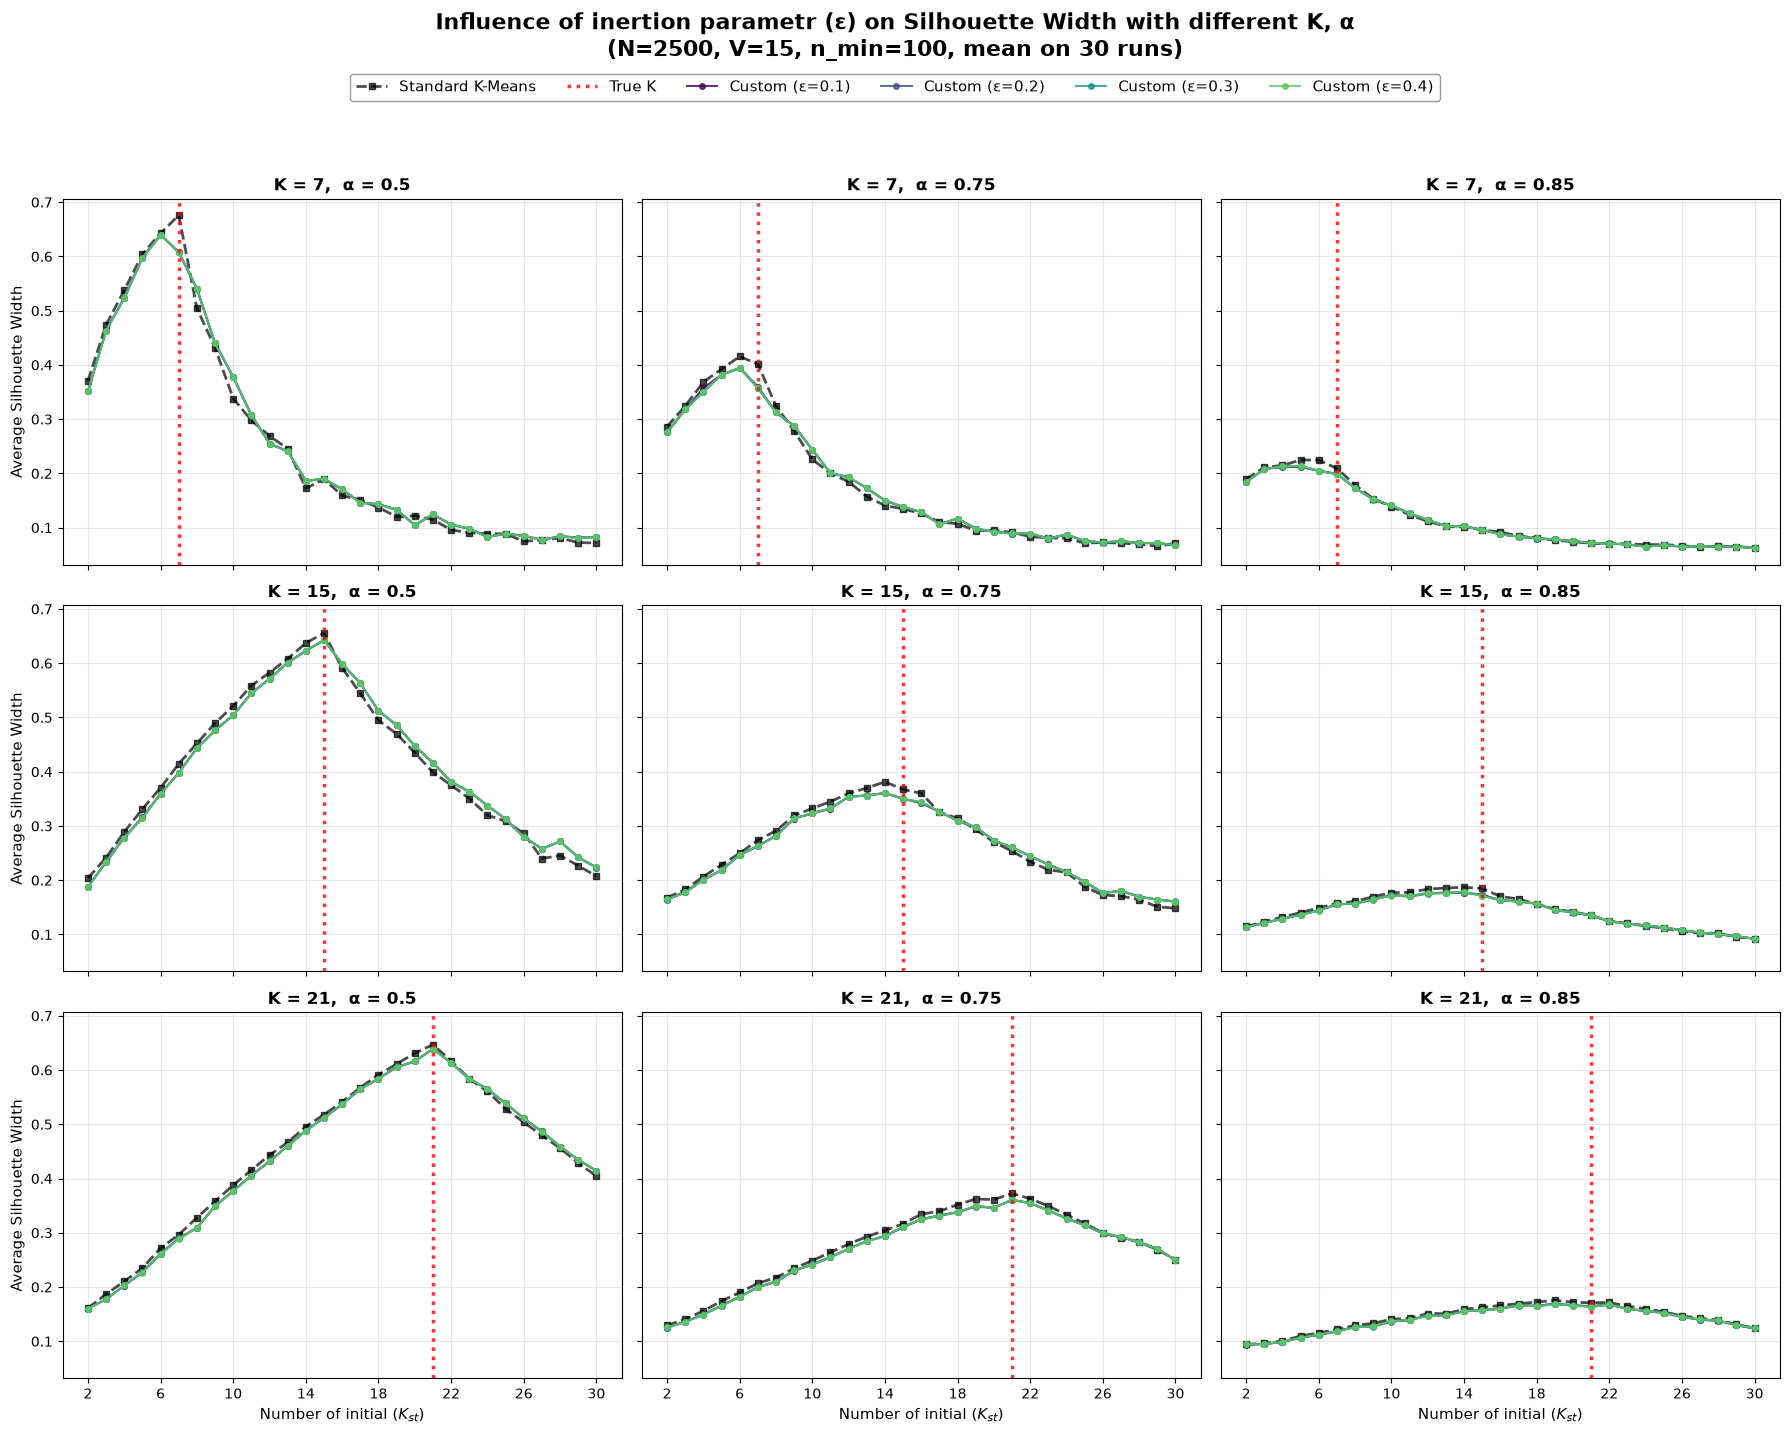

In [ ]:

PLOT_V = 15 

fig, axes = plt.subplots(len(K_list), len(alpha_list), figsize=(18, 14), sharex=True, sharey=True)

cmap = plt.get_cmap('viridis')
eps_colors = {eps: cmap(i / len(epsilon_list)) for i, eps in enumerate(epsilon_list)}

for row_idx, K in enumerate(K_list):
    for col_idx, alpha in enumerate(alpha_list):
        ax = axes[row_idx, col_idx]
        
        std_scores = [results[PLOT_V][K][alpha][k_st]['std'] for k_st in K_st_range]
        ax.plot(K_st_range, std_scores, marker='s', linestyle='--', color='black', 
                linewidth=2, markersize=5, alpha=0.7, label='Standard K-Means')
        
        for eps in [0.1, 0.2, 0.3, 0.4]:
            eps_scores = [results[PLOT_V][K][alpha][k_st][f'eps_{eps}'] for k_st in K_st_range]
            ax.plot(K_st_range, eps_scores, marker='o', linestyle='-', 
                    color=eps_colors[eps], linewidth=1.5, markersize=4, alpha=0.8,
                    label=f'Custom (ε={eps})')
        
        ax.axvline(x=K, color='red', linestyle=':', linewidth=2.5, alpha=0.8, label='True K' if col_idx == 0 else "")
                
        ax.set_title(f"K = {K},  α = {alpha}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(2, 31, 4))
        
        if row_idx == len(K_list) - 1:
            ax.set_xlabel("Number of initial ($K_{st}$)", fontsize=11)
        if col_idx == 0:
            ax.set_ylabel("Average Silhouette Width", fontsize=11)
        
        handles, labels = axes[0, 0].get_legend_handles_labels()
        custom_handles = [h for h, l in zip(handles, labels) if 'ε=' in l]
        custom_labels = [l for h, l in zip(handles, labels) if 'ε=' in l]
        std_handle = [h for h, l in zip(handles, labels) if 'Standard' in l][0]
        std_label = [l for h, l in zip(handles, labels) if 'Standard' in l][0]
        true_k_handle = [h for h, l in zip(handles, labels) if 'True' in l][0]
        true_k_label = [l for h, l in zip(handles, labels) if 'True' in l][0]
fig.legend([std_handle, true_k_handle] + custom_handles, 
           [std_label, true_k_label] + custom_labels, 
           loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=7, fontsize=11, frameon=True, edgecolor='gray')

fig.suptitle(f'Influence of inertion parametr (ε) on Silhouette Width with different K, α\n(N={N}, V={PLOT_V}, n_min={n_min}, mean on {n_runs} runs)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('SW_KMean_V15.jpg')
plt.show()


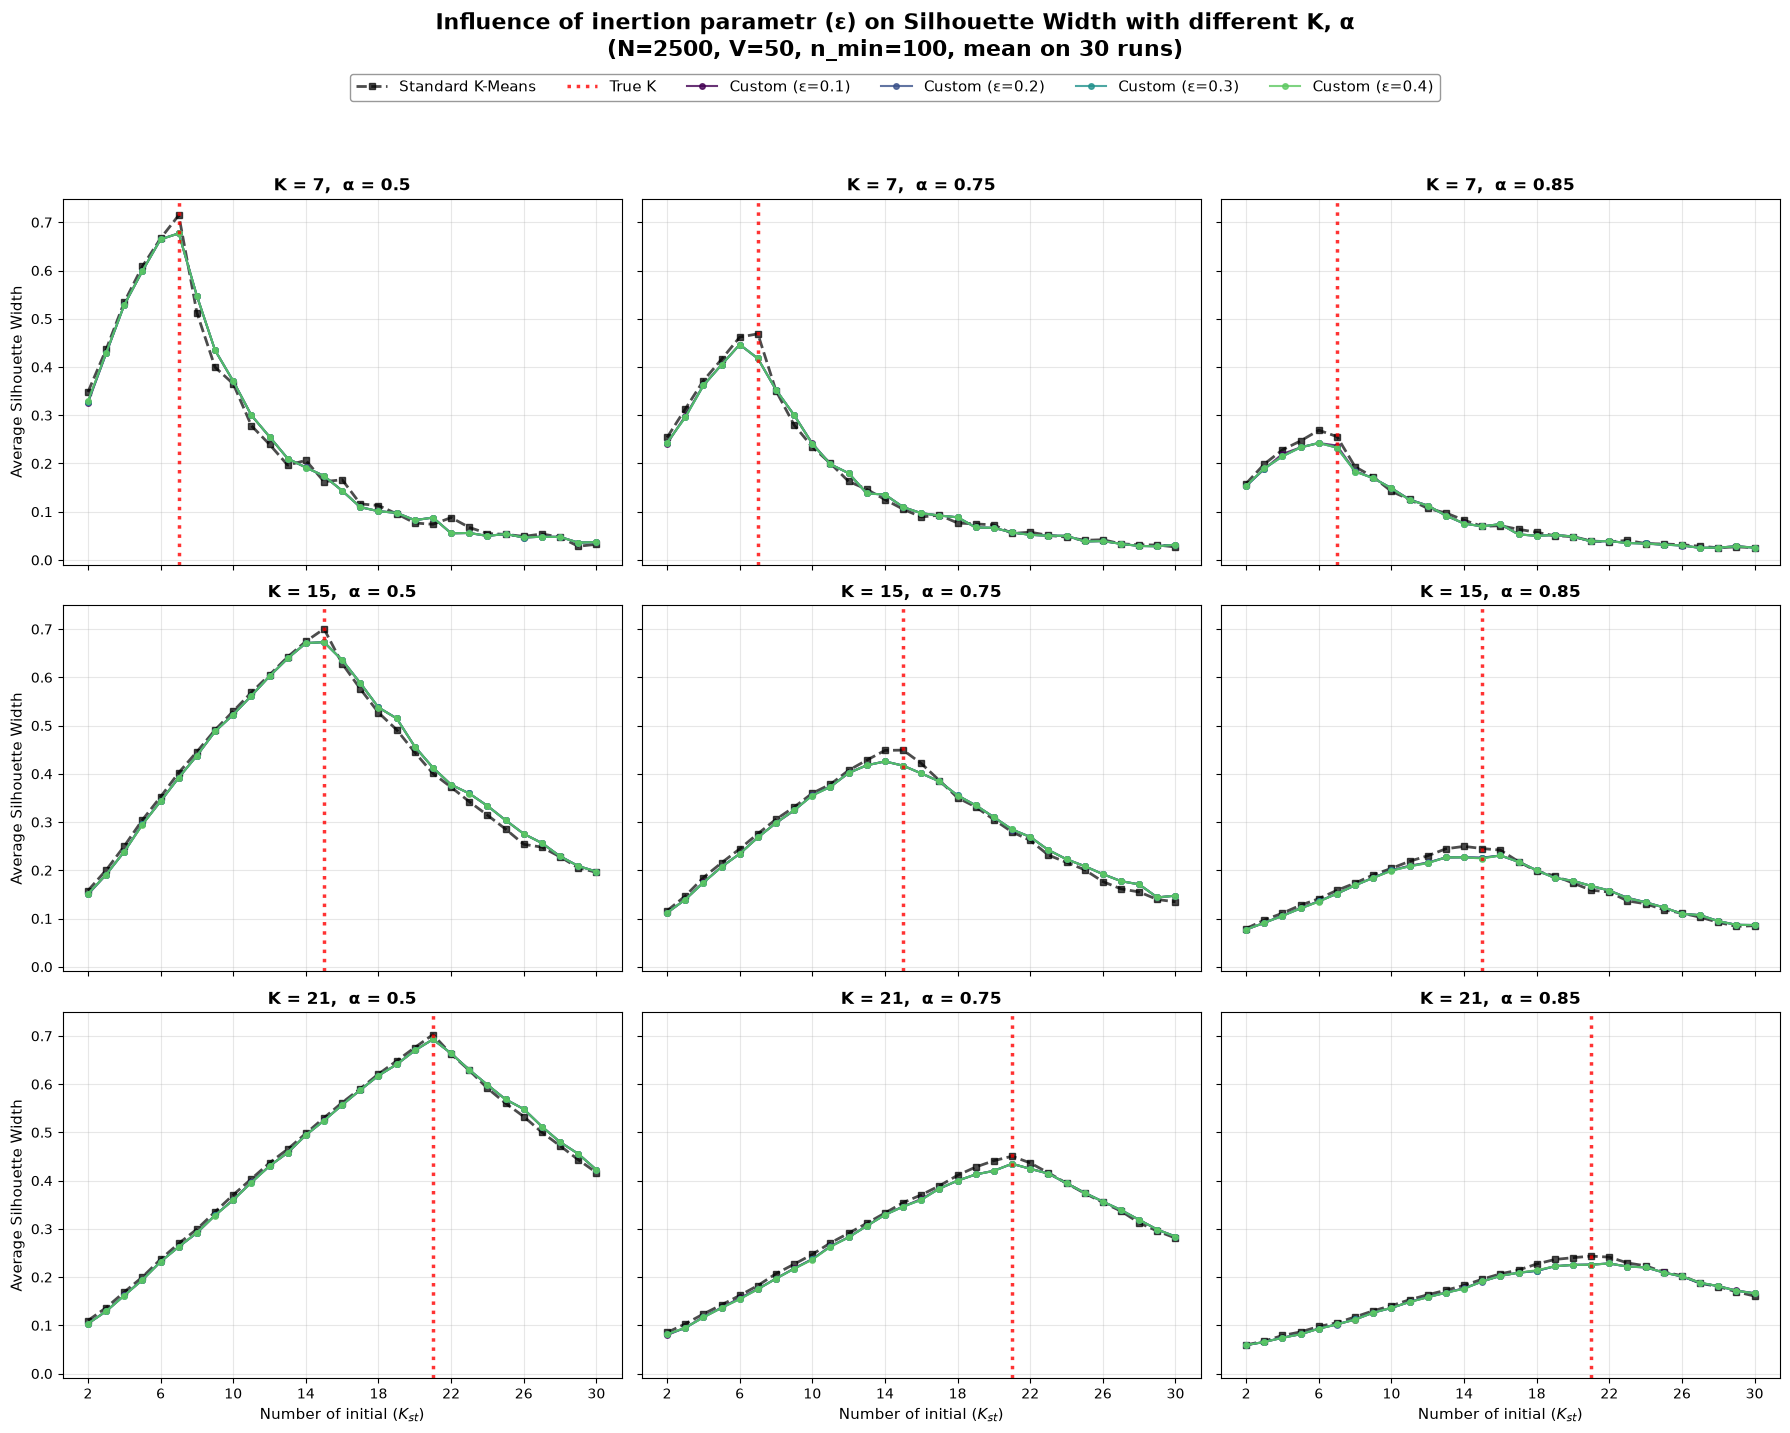

In [ ]:

PLOT_V = 50

fig, axes = plt.subplots(len(K_list), len(alpha_list), figsize=(18, 14), sharex=True, sharey=True)

cmap = plt.get_cmap('viridis')
eps_colors = {eps: cmap(i / len(epsilon_list)) for i, eps in enumerate(epsilon_list)}

for row_idx, K in enumerate(K_list):
    for col_idx, alpha in enumerate(alpha_list):
        ax = axes[row_idx, col_idx]
        
        std_scores = [results[PLOT_V][K][alpha][k_st]['std'] for k_st in K_st_range]
        ax.plot(K_st_range, std_scores, marker='s', linestyle='--', color='black', 
                linewidth=2, markersize=5, alpha=0.7, label='Standard K-Means')
        
        for eps in [0.1, 0.2, 0.3, 0.4]:
            eps_scores = [results[PLOT_V][K][alpha][k_st][f'eps_{eps}'] for k_st in K_st_range]
            ax.plot(K_st_range, eps_scores, marker='o', linestyle='-', 
                    color=eps_colors[eps], linewidth=1.5, markersize=4, alpha=0.8,
                    label=f'Custom (ε={eps})')
        
        ax.axvline(x=K, color='red', linestyle=':', linewidth=2.5, alpha=0.8, label='True K' if col_idx == 0 else "")
                
        ax.set_title(f"K = {K},  α = {alpha}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(2, 31, 4))
        
        if row_idx == len(K_list) - 1:
            ax.set_xlabel("Number of initial ($K_{st}$)", fontsize=11)
        if col_idx == 0:
            ax.set_ylabel("Average Silhouette Width", fontsize=11)
        
        handles, labels = axes[0, 0].get_legend_handles_labels()
        custom_handles = [h for h, l in zip(handles, labels) if 'ε=' in l]
        custom_labels = [l for h, l in zip(handles, labels) if 'ε=' in l]
        std_handle = [h for h, l in zip(handles, labels) if 'Standard' in l][0]
        std_label = [l for h, l in zip(handles, labels) if 'Standard' in l][0]
        true_k_handle = [h for h, l in zip(handles, labels) if 'True' in l][0]
        true_k_label = [l for h, l in zip(handles, labels) if 'True' in l][0]
fig.legend([std_handle, true_k_handle] + custom_handles, 
           [std_label, true_k_label] + custom_labels, 
           loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=7, fontsize=11, frameon=True, edgecolor='gray')

fig.suptitle(f'Influence of inertion parametr (ε) on Silhouette Width with different K, α\n(N={N}, V={PLOT_V}, n_min={n_min}, mean on {n_runs} runs)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('SW_KMean_V50.jpg')
plt.show()


In [227]:
import numpy as np
import pandas as pd
import time
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import adjusted_rand_score


N = 2500
n_min = 100
V_list = [15, 50]
K_list = [7, 15, 21]               
alpha_list = [0.5, 0.75, 0.85]
epsilon_list = [0.1, 0.2, 0.3, 0.4]
n_runs = 30

results = {V: {} for V in V_list}

start_time = time.time()

for V in V_list:
    for K in K_list:
        results[V][f"K={K}"] = {}

        for alpha in alpha_list:
            ari_std_list = []
            ari_eps_list = {eps: [] for eps in epsilon_list}
            
            for run in range(n_runs):
                seed = V * 100000 + K * 1000 + int(alpha * 100) * 10 + run
                Y, true_labels, _, _ = generate_clusters(N, V, K, n_min, alpha, seed=seed)
                
                labels_std = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=seed).fit_predict(Y)
                ari_std_list.append(adjusted_rand_score(true_labels, labels_std))
                
                for eps in epsilon_list:
                    _, labels_eps, _, _ = custom_kmeans_with_inertia(
                        Y, n_clusters=K, epsilon=eps, random_state=seed
                    )
                    ari_eps_list[eps].append(adjusted_rand_score(true_labels, labels_eps))
            
            results[V][f"K={K}"][f"α={alpha}"] = {
                "Standard": np.mean(ari_std_list),
                **{f"ε={eps}": np.mean(ari_eps_list[eps]) for eps in epsilon_list}
            }

print(f"Вычисления завершены за {time.time() - start_time:.1f} сек.\n")

pd.options.display.float_format = '{:.4f}'.format


Вычисления завершены за 62.0 сек.



In [228]:

for V in V_list:
    print(f"РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = {V}")
    table_data = {
        "Standard": [],
        "ε=0.1": [],
        "ε=0.2": [],
        "ε=0.3": [],
        "ε=0.4": []
    }
    
    columns = []
    for K in K_list: 
        for alpha in alpha_list:
            columns.append((f"K={K}", f"α={alpha}"))
            
            res = results[V][f"K={K}"][f"α={alpha}"]
            table_data["Standard"].append(res["Standard"])
            table_data["ε=0.1"].append(res["ε=0.1"])
            table_data["ε=0.2"].append(res["ε=0.2"])
            table_data["ε=0.3"].append(res["ε=0.3"])
            table_data["ε=0.4"].append(res["ε=0.4"])

    df = pd.DataFrame(table_data, index=pd.MultiIndex.from_tuples(columns, names=["Истинное K", "Параметр α"]))
    
    df = df.T
    
    print(df.to_string())
    print("\n")

РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 15
Истинное K    K=7                 K=15                 K=21              
Параметр α  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85
Standard   1.0000 0.9997 0.9380 1.0000 0.9989 0.9048 1.0000 0.9960 0.8896
ε=0.1      0.9514 0.9190 0.8157 0.9787 0.9250 0.8491 0.9701 0.9332 0.8344
ε=0.2      0.9514 0.9191 0.8155 0.9788 0.9246 0.8483 0.9701 0.9332 0.8328
ε=0.3      0.9514 0.9190 0.8156 0.9787 0.9247 0.8483 0.9702 0.9332 0.8348
ε=0.4      0.9514 0.9190 0.8155 0.9788 0.9223 0.8472 0.9702 0.9332 0.8289


РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 50
Истинное K    K=7                 K=15                 K=21              
Параметр α  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85
Standard   1.0000 0.9929 0.9828 1.0000 1.0000 0.9771 1.0000 0.9984 0.9866
ε=0.1      0.9823 0.9210 0.8420 0.9916 0.9488 0.9003 0.9948 0.9652 0.9358
ε=0.2      0.9823 0.9211 0.8417 0.9916 0.9488 0.9005 0.9948 0.9652 0.9357
ε=0.3      0.9

In [229]:
import numpy as np
import pandas as pd
import time
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import adjusted_rand_score


N = 6000
n_min = 100
V_list = [15, 40]
K_list = [23, 30, 57]               
alpha_list = [0.5, 0.75, 0.85]
epsilon_list = [0.1, 0.2, 0.3, 0.4]
n_runs = 30

results = {V: {} for V in V_list}

start_time = time.time()

for V in V_list:
    for K in K_list:
        results[V][f"K={K}"] = {}

        for alpha in alpha_list:
            ari_std_list = []
            ari_eps_list = {eps: [] for eps in epsilon_list}
            
            for run in range(n_runs):
                seed = V * 100000 + K * 1000 + int(alpha * 100) * 10 + run
                Y, true_labels, _, _ = generate_clusters(N, V, K, n_min, alpha, seed=seed)
                
                labels_std = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=seed).fit_predict(Y)
                ari_std_list.append(adjusted_rand_score(true_labels, labels_std))
                
                for eps in epsilon_list:
                    _, labels_eps, _, _ = custom_kmeans_with_inertia(
                        Y, n_clusters=K, epsilon=eps, random_state=seed
                    )
                    ari_eps_list[eps].append(adjusted_rand_score(true_labels, labels_eps))
            
            results[V][f"K={K}"][f"α={alpha}"] = {
                "Standard": np.mean(ari_std_list),
                **{f"ε={eps}": np.mean(ari_eps_list[eps]) for eps in epsilon_list}
            }

print(f"Вычисления завершены за {time.time() - start_time:.1f} сек.\n")

pd.options.display.float_format = '{:.4f}'.format


Вычисления завершены за 367.2 сек.



In [231]:

for V in V_list:
    print(f"РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = {V}")
    
    table_data = {
        "Standard": [],
        "ε=0.1": [],
        "ε=0.2": [],
        "ε=0.3": [],
        "ε=0.4": []
    }
    
    columns = []
    for K in K_list: 
        for alpha in alpha_list: 
            columns.append((f"K={K}", f"α={alpha}"))
            
            res = results[V][f"K={K}"][f"α={alpha}"]
            table_data["Standard"].append(res["Standard"])
            table_data["ε=0.1"].append(res["ε=0.1"])
            table_data["ε=0.2"].append(res["ε=0.2"])
            table_data["ε=0.3"].append(res["ε=0.3"])
            table_data["ε=0.4"].append(res["ε=0.4"])

    df = pd.DataFrame(table_data, index=pd.MultiIndex.from_tuples(columns, names=["Истинное K", "Параметр α"]))
    
    df = df.T
    
    print(df.to_string())
    print("\n")

РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 15
Истинное K   K=23                 K=30                 K=57              
Параметр α  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85
Standard   0.9952 0.9457 0.8275 0.9987 0.9489 0.8179 0.9972 0.9638 0.7719
ε=0.1      0.9509 0.8919 0.7875 0.9531 0.9106 0.7615 0.9715 0.9330 0.7457
ε=0.2      0.9509 0.8919 0.7880 0.9531 0.9117 0.7599 0.9714 0.9330 0.7443
ε=0.3      0.9509 0.8919 0.7870 0.9531 0.9109 0.7613 0.9715 0.9330 0.7428
ε=0.4      0.9509 0.8919 0.7873 0.9531 0.9104 0.7614 0.9715 0.9323 0.7425


РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 40
Истинное K   K=23                 K=30                 K=57              
Параметр α  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85
Standard   1.0000 0.9681 0.9257 1.0000 0.9763 0.9400 0.9992 0.9834 0.9654
ε=0.1      0.9691 0.9159 0.8535 0.9695 0.9243 0.8763 0.9836 0.9562 0.9328
ε=0.2      0.9691 0.9160 0.8533 0.9696 0.9242 0.8761 0.9836 0.9562 0.9320
ε=0.3      0.9

In [240]:
import numpy as np
import pandas as pd
import time
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import adjusted_rand_score


N = 6000
n_min = 20
V_list = [15]
K_list = [ 30, 57, 70]               
alpha_list = [ 0.8, 0.9]
epsilon_list = [0.1, 0.2, 0.3, 0.4]
n_runs = 30

results = {V: {} for V in V_list}

start_time = time.time()

for V in V_list:
    for K in K_list:
        results[V][f"K={K}"] = {}

        for alpha in alpha_list:
            ari_std_list = []
            ari_eps_list = {eps: [] for eps in epsilon_list}
            
            for run in range(n_runs):
                seed = V * 100000 + K * 1000 + int(alpha * 100) * 10 + run
                Y, true_labels, _, _ = generate_clusters(N, V, K, n_min, alpha, seed=seed)
                
                labels_std = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=seed).fit_predict(Y)
                ari_std_list.append(adjusted_rand_score(true_labels, labels_std))
                
                for eps in epsilon_list:
                    _, labels_eps, _, _ = custom_kmeans_with_inertia(
                        Y, n_clusters=K, epsilon=eps, random_state=seed
                    )
                    ari_eps_list[eps].append(adjusted_rand_score(true_labels, labels_eps))
            
            results[V][f"K={K}"][f"α={alpha}"] = {
                "Standard": np.mean(ari_std_list),
                **{f"ε={eps}": np.mean(ari_eps_list[eps]) for eps in epsilon_list}
            }

print(f"Вычисления завершены за {time.time() - start_time:.1f} сек.\n")

pd.options.display.float_format = '{:.4f}'.format


Вычисления завершены за 268.4 сек.



In [241]:

for V in V_list:
    print(f"РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = {V}")

    
    table_data = {
        "Standard": [],
        "ε=0.1": [],
        "ε=0.2": [],
        "ε=0.3": [],
        "ε=0.4": []
    }
    
    columns = []
    for K in K_list: 
        for alpha in alpha_list: 
            columns.append((f"K={K}", f"α={alpha}"))
            
            res = results[V][f"K={K}"][f"α={alpha}"]
            table_data["Standard"].append(res["Standard"])
            table_data["ε=0.1"].append(res["ε=0.1"])
            table_data["ε=0.2"].append(res["ε=0.2"])
            table_data["ε=0.3"].append(res["ε=0.3"])
            table_data["ε=0.4"].append(res["ε=0.4"])

    df = pd.DataFrame(table_data, index=pd.MultiIndex.from_tuples(columns, names=["Истинное K", "Параметр α"]))
    
    df = df.T
    
    print(df.to_string())
    print("\n")

РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 15
Истинное K   K=30          K=57          K=70       
Параметр α  α=0.8  α=0.9  α=0.8  α=0.9  α=0.8  α=0.9
Standard   0.8248 0.3790 0.8120 0.2710 0.8049 0.2365
ε=0.1      0.7943 0.3723 0.7728 0.2677 0.7758 0.2299
ε=0.2      0.7936 0.3728 0.7752 0.2668 0.7738 0.2313
ε=0.3      0.7908 0.3707 0.7762 0.2657 0.7752 0.2307
ε=0.4      0.7921 0.3705 0.7744 0.2660 0.7763 0.2319




In [234]:
import numpy as np
import pandas as pd
import time
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import adjusted_rand_score


N = 2000
n_min = 20
V_list = [15]
K_list = [ 10, 30, 57, 70]               
alpha_list = [ 0.3, 0.8]
epsilon_list = [0.1, 0.3, 0.4]
n_runs = 30

results = {V: {} for V in V_list}

start_time = time.time()

for V in V_list:
    for K in K_list:
        results[V][f"K={K}"] = {}

        for alpha in alpha_list:
            ari_std_list = []
            ari_eps_list = {eps: [] for eps in epsilon_list}
            
            for run in range(n_runs):
                seed = V * 100000 + K * 1000 + int(alpha * 100) * 10 + run
                Y, true_labels, _, _ = generate_clusters(N, V, K, n_min, alpha, seed=seed)
                
                labels_std = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=seed).fit_predict(Y)
                ari_std_list.append(adjusted_rand_score(true_labels, labels_std))
                
                for eps in epsilon_list:
                    _, labels_eps, _, _ = custom_kmeans_with_inertia(
                        Y, n_clusters=K, epsilon=eps, random_state=seed
                    )
                    ari_eps_list[eps].append(adjusted_rand_score(true_labels, labels_eps))
            
            results[V][f"K={K}"][f"α={alpha}"] = {
                "Standard": np.mean(ari_std_list),
                **{f"ε={eps}": np.mean(ari_eps_list[eps]) for eps in epsilon_list}
            }

print(f"Вычисления завершены за {time.time() - start_time:.1f} сек.\n")

pd.options.display.float_format = '{:.4f}'.format


Вычисления завершены за 34.9 сек.



In [235]:

for V in V_list:
    print(f"РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = {V}")
    
    table_data = {
        "Standard": [],
        "ε=0.1": [],
        "ε=0.3": [],
        "ε=0.4": []
    }
    
    columns = []
    for K in K_list: 
        for alpha in alpha_list: 
            columns.append((f"K={K}", f"α={alpha}"))
            
            res = results[V][f"K={K}"][f"α={alpha}"]
            table_data["Standard"].append(res["Standard"])
            table_data["ε=0.1"].append(res["ε=0.1"])
            table_data["ε=0.3"].append(res["ε=0.3"])
            table_data["ε=0.4"].append(res["ε=0.4"])

    df = pd.DataFrame(table_data, index=pd.MultiIndex.from_tuples(columns, names=["Истинное K", "Параметр α"]))
    
    df = df.T
    
    print(df.to_string())
    print("\n")

РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 15
Истинное K   K=10          K=30          K=57          K=70       
Параметр α  α=0.3  α=0.8  α=0.3  α=0.8  α=0.3  α=0.8  α=0.3  α=0.8
Standard   1.0000 0.8981 0.9987 0.8790 1.0000 0.8845 0.9981 0.8838
ε=0.1      0.9518 0.8140 0.9697 0.8176 0.9798 0.8445 0.9829 0.8544
ε=0.3      0.9518 0.8107 0.9698 0.8177 0.9798 0.8435 0.9829 0.8542
ε=0.4      0.9518 0.8109 0.9699 0.8189 0.9797 0.8436 0.9829 0.8506




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


df = pd.read_excel('/Users/sergey_perov/Desktop/K-means_research/s-originals/s4-groundtruth-plot.xls', header=None)
df = df.drop([0], axis=1)
print(df)
init_centers = df.iloc[:15].values

X = df.iloc[15:].values

print(f"Загружено центров: {init_centers.shape[0]}")
print(f"Загружено точек для кластеризации: {X.shape[0]}")

y_true = np.loadtxt('/Users/sergey_perov/Desktop/K-means_research/s-originals/s4-label.txt', dtype=int)

      

           1       2
0     645207  747013
1     304866  695374
2     730301  429068
3     770267  571916
4     536771  514289
...      ...     ...
5010  540118  671072
5011  507453  777031
5012  569266  738385
5013  444587  878830
5014  434041  814466

[5015 rows x 2 columns]
Загружено центров: 15
Загружено точек для кластеризации: 5000

Adjusted Rand Index (ARI) сравнение с txt: 0.6328993964624271
0.5933440141086185


In [259]:
cust_im = 0.0
all_d = 0.0
for i in range(0, 30000):
    all_d += 1
    kmeans = KMeans(
        n_clusters=15,                      
        n_init=1,                  
        max_iter=300,              
        random_state=i            
    )

    y_pred = kmeans.fit_predict(X)

    ari_score_st = adjusted_rand_score(y_true, y_pred)
    #print(f"\nAdjusted Rand Index (ARI) сравнение с txt: {ari_score}")
    _, labels_eps, _, _ = custom_kmeans_with_inertia(
                        X, n_clusters=15, epsilon=0.3, random_state=i
                    )
    ari_score_cus = adjusted_rand_score(y_true, labels_eps)
    if ari_score_cus > ari_score_st:
            cust_im += 1
print(cust_im, all_d)
print(cust_im / all_d)


16235.0 30000.0
0.5411666666666667


We see that when Kmeans runs 1 time and custom algorithn also launched once the result of compilation shows us that ARI with >50% chance is higher using custom K-means

In [261]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
ecoli = fetch_ucirepo(id=39) 
  
# data (as pandas dataframes) 
X = ecoli.data.features 
y = ecoli.data.targets 
  
# metadata 
print(ecoli.metadata) 
  
# variable information 
print(ecoli.variables) 
Y, uniques = pd.factorize(y['class'])


{'uci_id': 39, 'name': 'Ecoli', 'repository_url': 'https://archive.ics.uci.edu/dataset/39/ecoli', 'data_url': 'https://archive.ics.uci.edu/static/public/39/data.csv', 'abstract': 'This data contains protein localization sites', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 336, 'num_features': 7, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': ['Sequence'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1996, 'last_updated': 'Thu Feb 15 2024', 'dataset_doi': '10.24432/C5388M', 'creators': ['Kenta Nakai'], 'intro_paper': {'ID': 391, 'type': 'NATIVE', 'title': 'A Probabilistic Classification System for Predicting the Cellular Localization Sites of Proteins', 'authors': 'P. Horton, K. Nakai', 'venue': 'Intelligent Systems in Molecular Biology', 'year': 1996, 'journal': None, 'DOI': None, 'URL': 'https://www.semanticscholar.org/paper/A-Probabilistic-Classific

In [262]:
i = 0.0
A = 0.0
for t_seed in range(0, 30000):
    A +=1
    kmeans = KMeans(
    n_clusters=7,             
    n_init=1,                  
    max_iter=300,              
    random_state=t_seed            
    )

    y_pred = kmeans.fit_predict(X.values)

    ari_score = adjusted_rand_score(Y, y_pred)

    #print(ari_score, kmeans.n_iter_)


    _, labels_eps, _, n_iter = custom_kmeans_with_inertia(
                            X.values, n_clusters=7, epsilon=0.2, random_state=t_seed
                        )
    if(ari_score < adjusted_rand_score(Y, labels_eps)):
        i+=1
        #print(f"Seed = {t_seed}, Kmeans_std_ari = {ari_score}, Kmeans_cust_ari = {adjusted_rand_score(Y, labels_eps)} ")
    #print(adjusted_rand_score(Y, labels_eps), n_iter)
print(A, i)
print(i/A)

30000.0 6816.0
0.2272


That means that our custom algorithm can show better results than the ordinary one

In [263]:
import numpy as np
import pandas as pd
import time
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import adjusted_rand_score


N = 2500
n_min = 100
V_list = [15, 50]
K_list = [7, 15, 21]               
alpha_list = [0.5, 0.75, 0.85]
epsilon_list = [0.1, 0.2, 0.3, 0.4]
n_runs = 30

results = {V: {} for V in V_list}

start_time = time.time()

for V in V_list:
    for K in K_list:
        results[V][f"K={K}"] = {}

        for alpha in alpha_list:
            ari_std_list = []
            ari_eps_list = {eps: [] for eps in epsilon_list}
            
            for run in range(n_runs):
                seed = V * 100000 + K * 1000 + int(alpha * 100) * 10 + run
                Y, true_labels, _, _ = generate_clusters(N, V, K, n_min, alpha, seed=seed)
                
                labels_std = KMeans(n_clusters=K, init='k-means++', n_init=1, random_state=seed).fit_predict(Y)
                ari_std_list.append(adjusted_rand_score(true_labels, labels_std))
                
                for eps in epsilon_list:
                    _, labels_eps, _, _ = custom_kmeans_with_inertia(
                        Y, n_clusters=K, epsilon=eps, random_state=seed
                    )
                    ari_eps_list[eps].append(adjusted_rand_score(true_labels, labels_eps))
            
            results[V][f"K={K}"][f"α={alpha}"] = {
                "Standard": np.mean(ari_std_list),
                **{f"ε={eps}": np.mean(ari_eps_list[eps]) for eps in epsilon_list}
            }

print(f"Вычисления завершены за {time.time() - start_time:.1f} сек.\n")

pd.options.display.float_format = '{:.4f}'.format


Вычисления завершены за 48.2 сек.



In [264]:

for V in V_list:
    print(f"РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = {V}")
    table_data = {
        "Standard": [],
        "ε=0.1": [],
        "ε=0.2": [],
        "ε=0.3": [],
        "ε=0.4": []
    }
    
    columns = []
    for K in K_list: 
        for alpha in alpha_list:
            columns.append((f"K={K}", f"α={alpha}"))
            
            res = results[V][f"K={K}"][f"α={alpha}"]
            table_data["Standard"].append(res["Standard"])
            table_data["ε=0.1"].append(res["ε=0.1"])
            table_data["ε=0.2"].append(res["ε=0.2"])
            table_data["ε=0.3"].append(res["ε=0.3"])
            table_data["ε=0.4"].append(res["ε=0.4"])

    df = pd.DataFrame(table_data, index=pd.MultiIndex.from_tuples(columns, names=["Истинное K", "Параметр α"]))
    
    df = df.T
    
    print(df.to_string())
    print("\n")

РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 15
Истинное K    K=7                 K=15                 K=21              
Параметр α  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85
Standard   0.9514 0.9191 0.8075 0.9788 0.9244 0.8485 0.9701 0.9332 0.8322
ε=0.1      0.9514 0.9190 0.8157 0.9787 0.9250 0.8491 0.9701 0.9332 0.8344
ε=0.2      0.9514 0.9191 0.8155 0.9788 0.9246 0.8483 0.9701 0.9332 0.8328
ε=0.3      0.9514 0.9190 0.8156 0.9787 0.9247 0.8483 0.9702 0.9332 0.8348
ε=0.4      0.9514 0.9190 0.8155 0.9788 0.9223 0.8472 0.9702 0.9332 0.8289


РЕЗУЛЬТАТЫ ARI (Adjusted Rand Index) для V = 50
Истинное K    K=7                 K=15                 K=21              
Параметр α  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85  α=0.5 α=0.75 α=0.85
Standard   0.9824 0.9210 0.8467 0.9917 0.9487 0.8975 0.9948 0.9650 0.9356
ε=0.1      0.9823 0.9210 0.8420 0.9916 0.9488 0.9003 0.9948 0.9652 0.9358
ε=0.2      0.9823 0.9211 0.8417 0.9916 0.9488 0.9005 0.9948 0.9652 0.9357
ε=0.3      0.9

In [265]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import silhouette_score
import time

N = 2500
n_min = 100  

V_list = [15, 50]
K_list = [7, 15, 21]
alpha_list = [0.5, 0.75, 0.85]
K_st_range = list(range(2, 31))
n_runs = 50  
epsilon_list = [0.1, 0.2, 0.3, 0.4]

results = {}

total_combinations = len(V_list) * len(K_list) * len(alpha_list)
current_combination = 0
global_start_time = time.time()


for V in V_list:
    results[V] = {}
    for K in K_list:
        results[V][K] = {}
        for alpha in alpha_list:
            results[V][K][alpha] = {}
            current_combination += 1
            print(f"[{current_combination}/{total_combinations}] V={V:2d}, K={K:2d}, alpha={alpha} ...", end=" ", flush=True)
            step_start = time.time()
            
            for k_st in K_st_range:
                scores_std = []
                scores_eps = {eps: [] for eps in epsilon_list}
                
                for run in range(n_runs):
                    seed = current_combination * 100000 + k_st * 1000 + run
                    Y, _, _, _ = generate_clusters(N, V, K, n_min, alpha, seed=seed)
                    
                    labels_std = KMeans(n_clusters=k_st, init='k-means++', n_init=1, random_state=seed).fit_predict(Y)
                    scores_std.append(silhouette_score(Y, labels_std))
                    
                    for eps in epsilon_list:
                        _, labels_eps, _, _ = custom_kmeans_with_inertia(
                            Y, n_clusters=k_st, epsilon=eps, random_state=seed, init='k-means++'
                        )
                        scores_eps[eps].append(silhouette_score(Y, labels_eps))
                
                results[V][K][alpha][k_st] = {
                    'std': np.mean(scores_std),
                    **{f'eps_{eps}': np.mean(scores_eps[eps]) for eps in epsilon_list}
                }
            
            print(f"{time.time() - step_start:.1f} seconds")

print(f"\nfull time {time.time() - global_start_time:.1f} seconds.")



[1/18] V=15, K= 7, alpha=0.5 ... 414.4 seconds
[2/18] V=15, K= 7, alpha=0.75 ... 428.9 seconds
[3/18] V=15, K= 7, alpha=0.85 ... 452.5 seconds
[4/18] V=15, K=15, alpha=0.5 ... 415.7 seconds
[5/18] V=15, K=15, alpha=0.75 ... 424.6 seconds
[6/18] V=15, K=15, alpha=0.85 ... 445.5 seconds
[7/18] V=15, K=21, alpha=0.5 ... 403.0 seconds
[8/18] V=15, K=21, alpha=0.75 ... 416.2 seconds
[9/18] V=15, K=21, alpha=0.85 ... 445.1 seconds
[10/18] V=50, K= 7, alpha=0.5 ... 596.3 seconds
[11/18] V=50, K= 7, alpha=0.75 ... 592.3 seconds
[12/18] V=50, K= 7, alpha=0.85 ... 582.7 seconds
[13/18] V=50, K=15, alpha=0.5 ... 484.3 seconds
[14/18] V=50, K=15, alpha=0.75 ... 501.8 seconds
[15/18] V=50, K=15, alpha=0.85 ... 513.8 seconds
[16/18] V=50, K=21, alpha=0.5 ... 449.9 seconds
[17/18] V=50, K=21, alpha=0.75 ... 459.3 seconds
[18/18] V=50, K=21, alpha=0.85 ... 474.5 seconds

full time 8501.0 seconds.


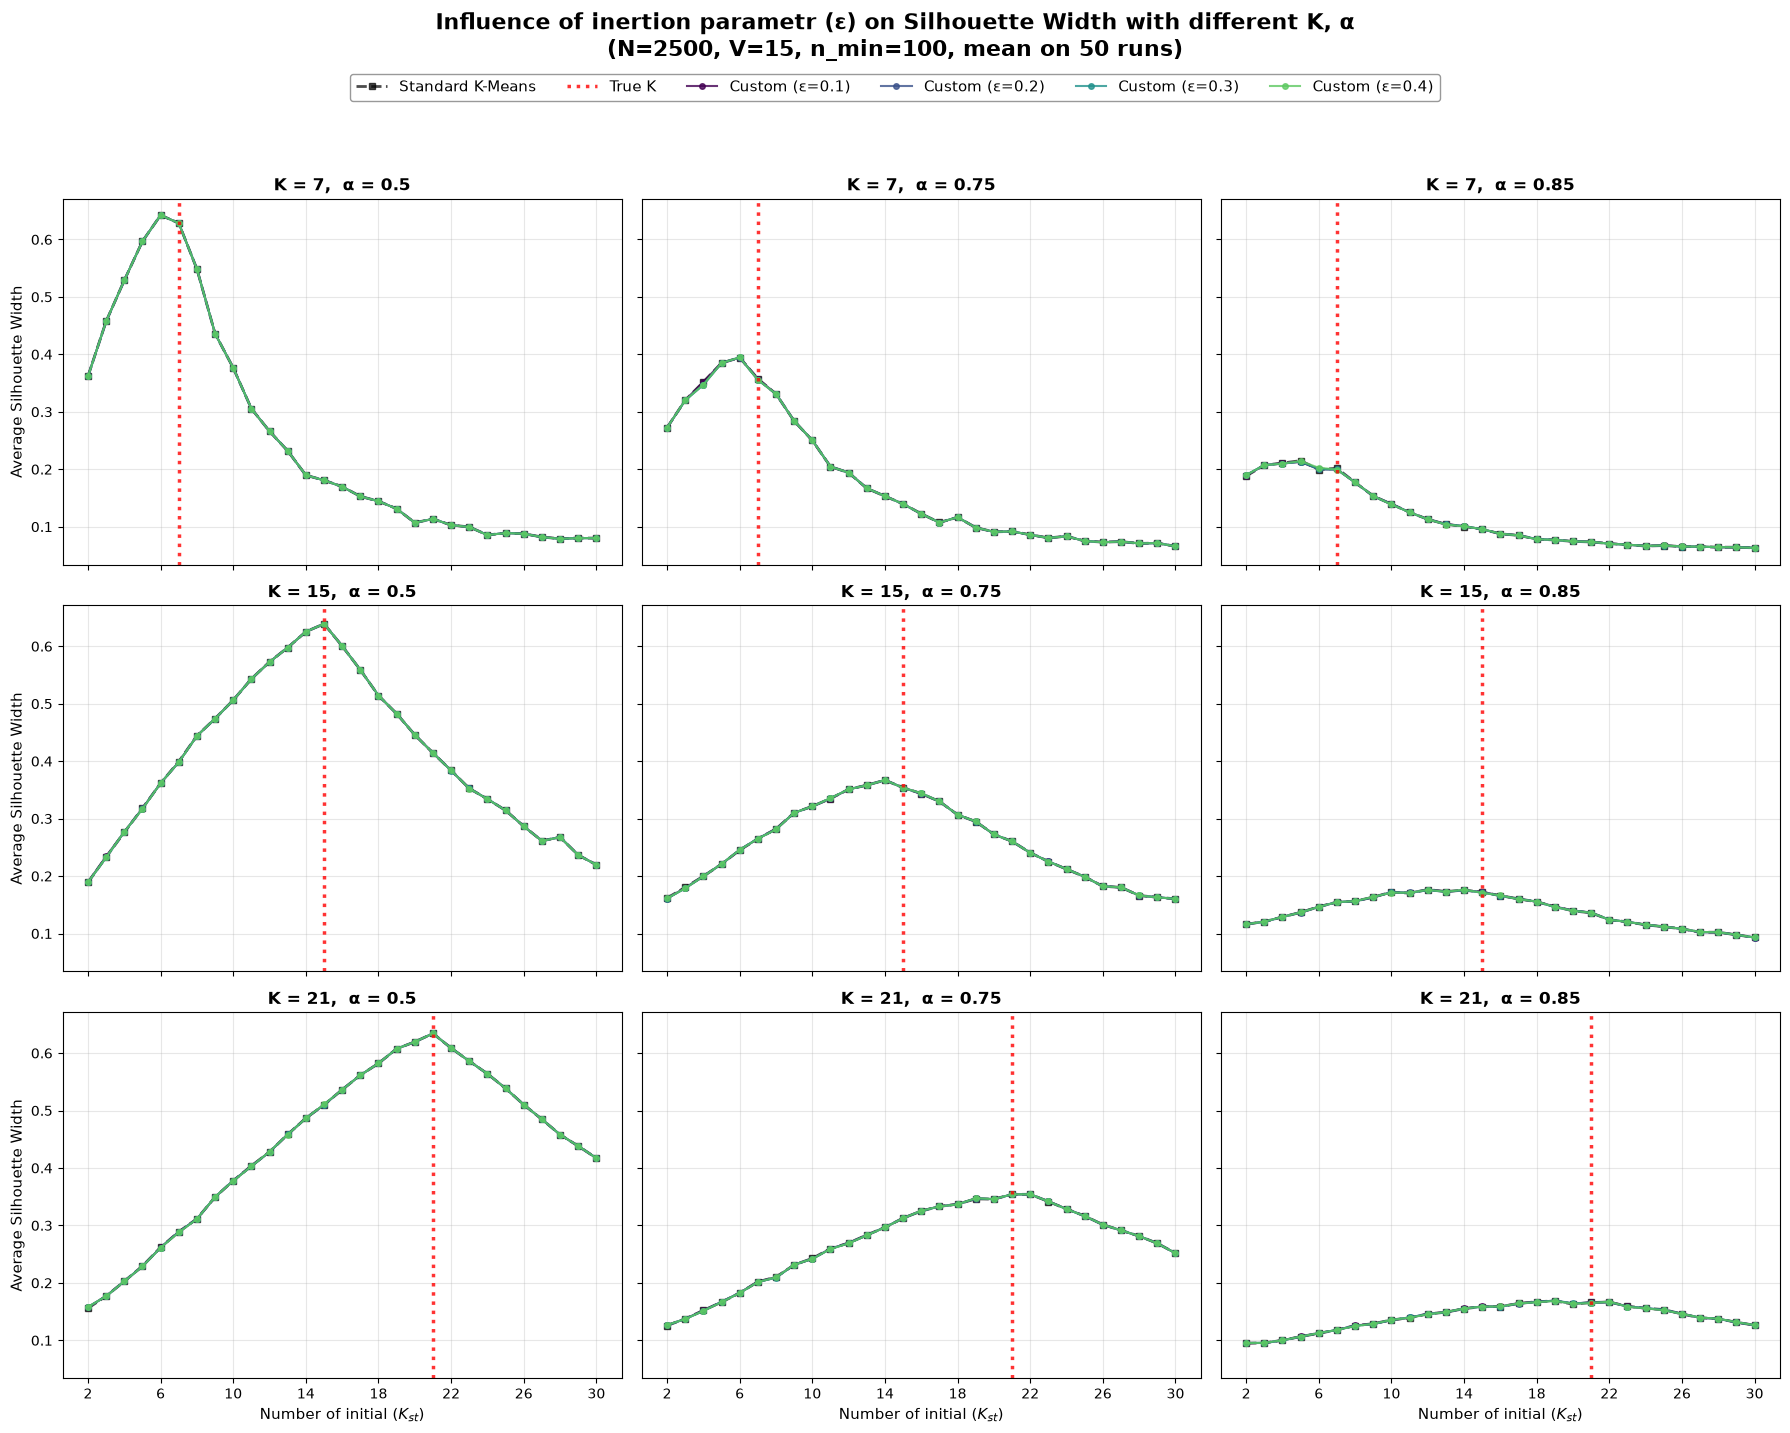

In [299]:

PLOT_V = 15 

fig, axes = plt.subplots(len(K_list), len(alpha_list), figsize=(18, 14), sharex=True, sharey=True)

cmap = plt.get_cmap('viridis')
eps_colors = {eps: cmap(i / len(epsilon_list)) for i, eps in enumerate(epsilon_list)}

for row_idx, K in enumerate(K_list):
    for col_idx, alpha in enumerate(alpha_list):
        ax = axes[row_idx, col_idx]
        
        std_scores = [results[PLOT_V][K][alpha][k_st]['std'] for k_st in K_st_range]
        ax.plot(K_st_range, std_scores, marker='s', linestyle='--', color='black', 
                linewidth=2, markersize=5, alpha=0.7, label='Standard K-Means')
        
        for eps in [0.1, 0.2, 0.3, 0.4]:
            eps_scores = [results[PLOT_V][K][alpha][k_st][f'eps_{eps}'] for k_st in K_st_range]
            ax.plot(K_st_range, eps_scores, marker='o', linestyle='-', 
                    color=eps_colors[eps], linewidth=1.5, markersize=4, alpha=0.8,
                    label=f'Custom (ε={eps})')
        
        ax.axvline(x=K, color='red', linestyle=':', linewidth=2.5, alpha=0.8, label='True K' if col_idx == 0 else "")
                
        ax.set_title(f"K = {K},  α = {alpha}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(2, 31, 4))
        
        if row_idx == len(K_list) - 1:
            ax.set_xlabel("Number of initial ($K_{st}$)", fontsize=11)
        if col_idx == 0:
            ax.set_ylabel("Average Silhouette Width", fontsize=11)
        
        handles, labels = axes[0, 0].get_legend_handles_labels()
        custom_handles = [h for h, l in zip(handles, labels) if 'ε=' in l]
        custom_labels = [l for h, l in zip(handles, labels) if 'ε=' in l]
        std_handle = [h for h, l in zip(handles, labels) if 'Standard' in l][0]
        std_label = [l for h, l in zip(handles, labels) if 'Standard' in l][0]
        true_k_handle = [h for h, l in zip(handles, labels) if 'True' in l][0]
        true_k_label = [l for h, l in zip(handles, labels) if 'True' in l][0]
fig.legend([std_handle, true_k_handle] + custom_handles, 
           [std_label, true_k_label] + custom_labels, 
           loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=7, fontsize=11, frameon=True, edgecolor='gray')

fig.suptitle(f'Influence of inertion parametr (ε) on Silhouette Width with different K, α\n(N={N}, V={PLOT_V}, n_min={n_min}, mean on {n_runs} runs)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('SW_KMean_V15_1sh.jpg')
plt.show()


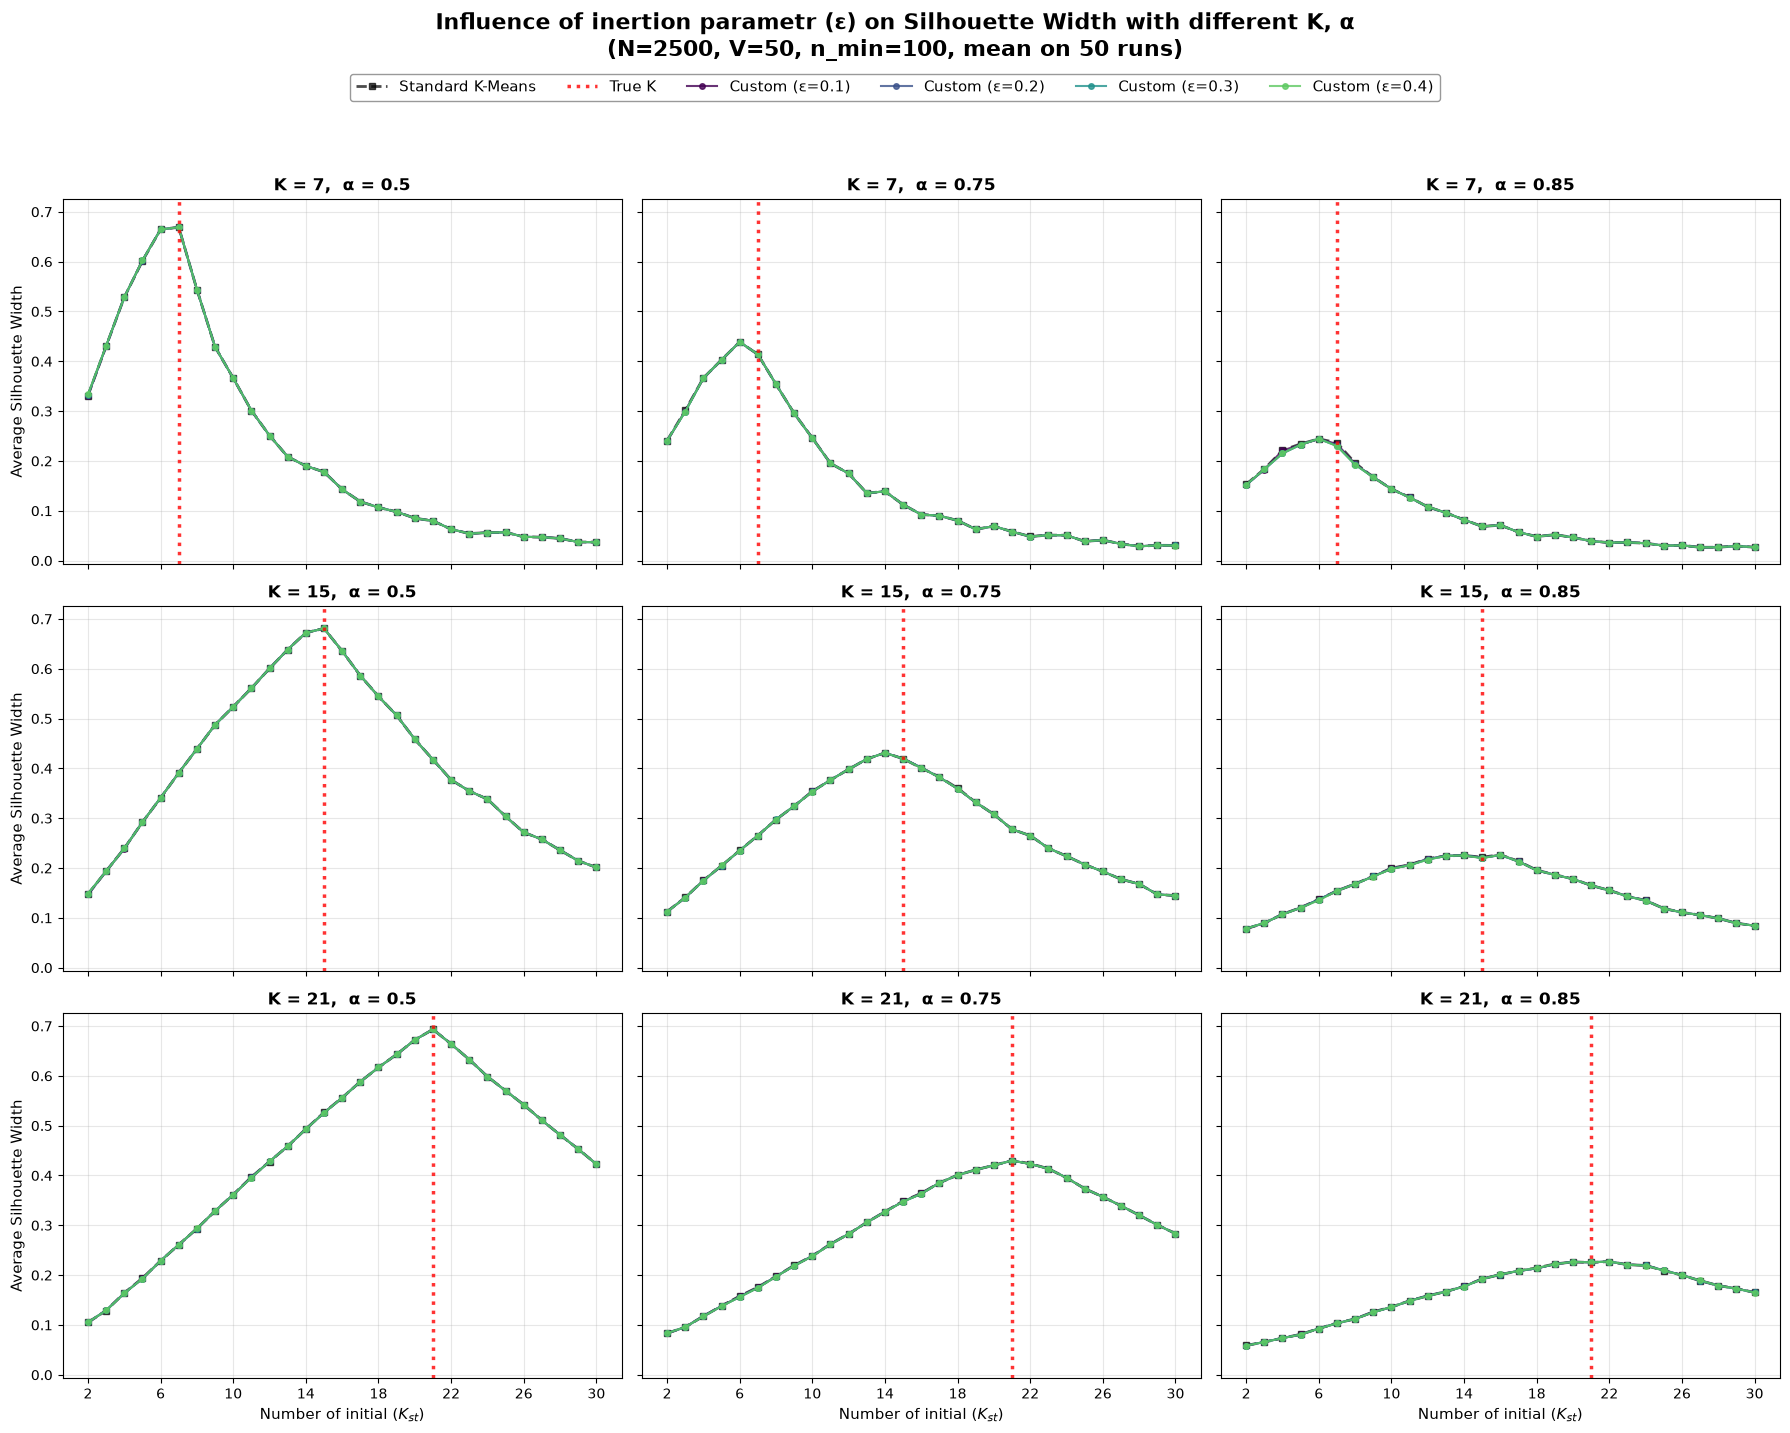

In [298]:

PLOT_V = 50

fig, axes = plt.subplots(len(K_list), len(alpha_list), figsize=(18, 14), sharex=True, sharey=True)

cmap = plt.get_cmap('viridis')
eps_colors = {eps: cmap(i / len(epsilon_list)) for i, eps in enumerate(epsilon_list)}

for row_idx, K in enumerate(K_list):
    for col_idx, alpha in enumerate(alpha_list):
        ax = axes[row_idx, col_idx]
        
        std_scores = [results[PLOT_V][K][alpha][k_st]['std'] for k_st in K_st_range]
        ax.plot(K_st_range, std_scores, marker='s', linestyle='--', color='black', 
                linewidth=2, markersize=5, alpha=0.7, label='Standard K-Means')
        
        for eps in [0.1, 0.2, 0.3, 0.4]:
            eps_scores = [results[PLOT_V][K][alpha][k_st][f'eps_{eps}'] for k_st in K_st_range]
            ax.plot(K_st_range, eps_scores, marker='o', linestyle='-', 
                    color=eps_colors[eps], linewidth=1.5, markersize=4, alpha=0.8,
                    label=f'Custom (ε={eps})')
        
        ax.axvline(x=K, color='red', linestyle=':', linewidth=2.5, alpha=0.8, label='True K' if col_idx == 0 else "")
                
        ax.set_title(f"K = {K},  α = {alpha}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(2, 31, 4))
        
        if row_idx == len(K_list) - 1:
            ax.set_xlabel("Number of initial ($K_{st}$)", fontsize=11)
        if col_idx == 0:
            ax.set_ylabel("Average Silhouette Width", fontsize=11)
        
        handles, labels = axes[0, 0].get_legend_handles_labels()
        custom_handles = [h for h, l in zip(handles, labels) if 'ε=' in l]
        custom_labels = [l for h, l in zip(handles, labels) if 'ε=' in l]
        std_handle = [h for h, l in zip(handles, labels) if 'Standard' in l][0]
        std_label = [l for h, l in zip(handles, labels) if 'Standard' in l][0]
        true_k_handle = [h for h, l in zip(handles, labels) if 'True' in l][0]
        true_k_label = [l for h, l in zip(handles, labels) if 'True' in l][0]
fig.legend([std_handle, true_k_handle] + custom_handles, 
           [std_label, true_k_label] + custom_labels, 
           loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=7, fontsize=11, frameon=True, edgecolor='gray')

fig.suptitle(f'Influence of inertion parametr (ε) on Silhouette Width with different K, α\n(N={N}, V={PLOT_V}, n_min={n_min}, mean on {n_runs} runs)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('SW_KMean_V50_1sh.jpg')
plt.show()
